In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas

Point 1: x=365, y=30
Point 2: x=343, y=141
Points: [(365, 30), (343, 141)]


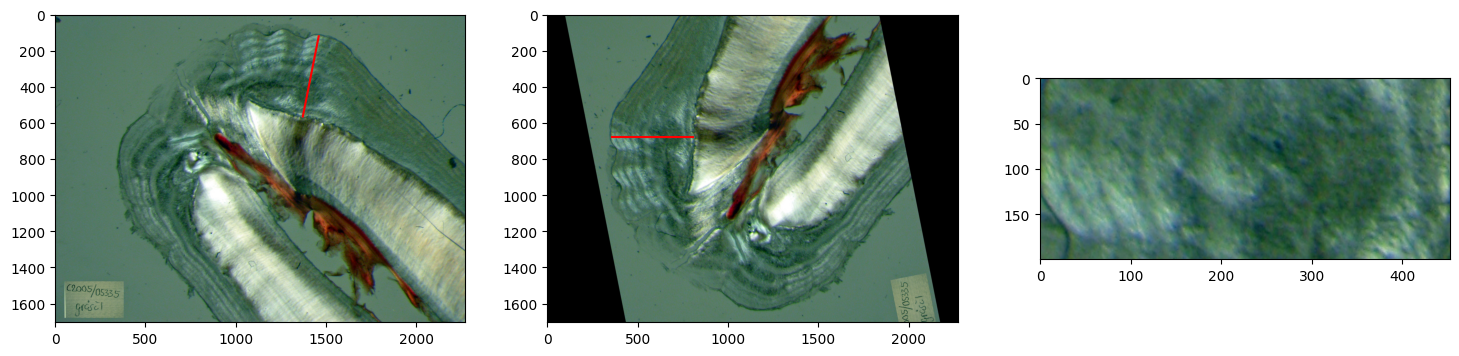

In [87]:
points = []

def get_points(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        points.append((x, y))
        print(f"Point {len(points)}: x={x}, y={y}")

def rotate_point(x, y, M):
    x_new = M[0, 0]*x + M[0, 1]*y + M[0, 2]
    y_new = M[1, 0]*x + M[1, 1]*y + M[1, 2]
    return x_new, y_new


## ThIS IS A FUNCTION FOR CUTTING OUT 1 REGION IN THE IMAGE 
## AROUND EDGES, THIS METHOD WILL FAIL AS OF NOW 

def create_samples(path):
    # points from clickcs
    I = cv2.imread(path)
    I_h, I_w = I.shape[:2]
    I = cv2.cvtColor(I, cv2.COLOR_BGR2RGB)
    scale = 0.25
    I_small = cv2.resize(I, (int(I_w*scale), int(I_h*scale)))
    cv2.imshow("Click points", I_small)      
    cv2.setMouseCallback("Click points", get_points)

    while True:
        cv2.waitKey(1)
        if len(points) >= 2:
            break

    cv2.destroyAllWindows()
    print(f'Points: {points}')
    x_1 = points[0][0] * 4
    x_2 = points[1][0] * 4 
    y_1 = points[0][1] * 4
    y_2 = points[1][1] * 4
    dx = x_2 - x_1
    dy = y_2 - y_1
    angle_rad = np.arctan2(dy, dx)
    angle_deg = np.degrees(angle_rad)
    center = (I_w // 2, I_h // 2)
    M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)
    rotated = cv2.warpAffine(I, M, (I_w, I_h))
    p1r = rotate_point(x_1, y_1, M)
    p2r = rotate_point(x_2, y_2, M)

    y_min = int(min(p1r[1], p2r[1]) - 100)
    y_max = int(max(p1r[1], p2r[1]) + 100)
    x_min = int(min(p1r[0], p2r[0]))
    x_max = int(max(p1r[0], p2r[0]))
    y_min = max(y_min, 0)
    y_max = min(y_max, I_h)
    x_min = max(x_min, 0)
    x_max = min(x_max, I_w)
    cropped = rotated[y_min:y_max, x_min:x_max]
    
    f, a = plt.subplots(1, 3, figsize=(18, 6))
    a = a.ravel()
    a[0].imshow(I)
    a[0].plot([x_1, x_2], [y_1, y_2], 'red')
    a[1].imshow(rotated)
    a[1].plot([p1r[0], p2r[0]], [p1r[1], p2r[1]], 'red')
    a[2].imshow(cropped)


    
path = r'uploads\c200505335.jpg'
create_samples(path)

In [ ]:
def get_points(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        points.append((x, y))
        print(f"Point {len(points)}: x={x}, y={y}")

points = []

path = r'uploads\c200505335.jpg'
I = cv2.imread(path)
I_h, I_w = I.shape[:2]
I_rgb = cv2.cvtColor(I, cv2.COLOR_BGR2RGB)
scale = 0.25
I_small = cv2.resize(I, (int(I_w*scale), int(I_h*scale)))
margin = int(300*scale)


#cv2.line(I_small, (margin, 0), (margin, I_small.shape[0]), (0, 0, 255), 1)       
#cv2.line(I_small, (I_small.shape[1] - margin, 0),
#         (I_small.shape[1] - margin, I_small.shape[0]), (0, 0, 255), 1)              
#cv2.line(I_small, (0, margin), (I_small.shape[1], margin), (0, 0, 255), 1)           
#cv2.line(I_small, (0, I_small.shape[0] - margin),
#         (I_small.shape[1], I_small.shape[0] - margin), (0, 0, 255), 1)        
cv2.imshow("Click points", I_small)      
cv2.setMouseCallback("Click points", get_points)

while True:
    cv2.waitKey(1)
    if len(points) >= 2:
        break

cv2.destroyAllWindows()
print(f'Points: {points}')


Point 1: x=318, y=20
Point 2: x=321, y=137
Points: [(318, 20), (321, 137)]


Angle: -88.53°


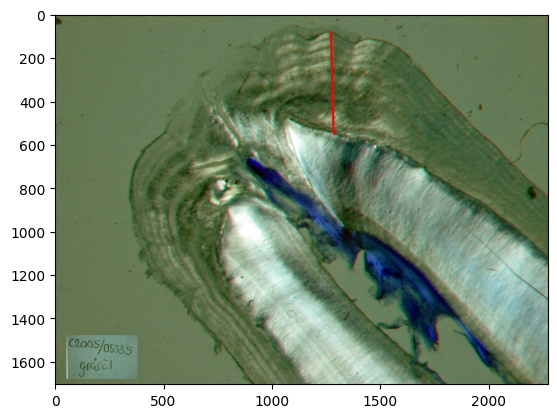

In [76]:
x_1 = points[0][0] * 4
x_2 = points[1][0] * 4 
y_1 = points[0][1] * 4
y_2 = points[1][1] * 4

margin = 100
I_h, I_w = I.shape[:2]

plt.figure()
plt.imshow(I)
plt.plot([x_1, x_2], [y_1, y_2], 'red')


dx = x_2 - x_1
dy = y_2 - y_1
angle_rad = np.arctan2(dy, dx)
angle_deg = np.degrees(angle_rad)
print(f"Angle: {-angle_deg:.2f}°")

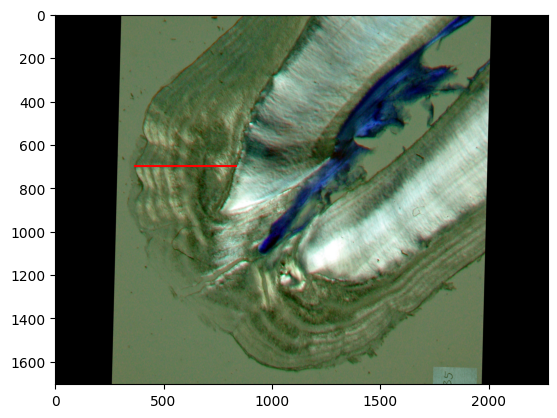

In [77]:
def rotate_point(x, y, M):
    x_new = M[0, 0]*x + M[0, 1]*y + M[0, 2]
    y_new = M[1, 0]*x + M[1, 1]*y + M[1, 2]
    return x_new, y_new

(h, w) = I.shape[:2]
center = (w // 2, h // 2)

M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)
rotated = cv2.warpAffine(I, M, (w, h))
plt.imshow(rotated)

p1r = rotate_point(x_1, y_1, M)
p2r = rotate_point(x_2, y_2, M)
plt.plot([p1r[0], p2r[0]], [p1r[1], p2r[1]], 'red')


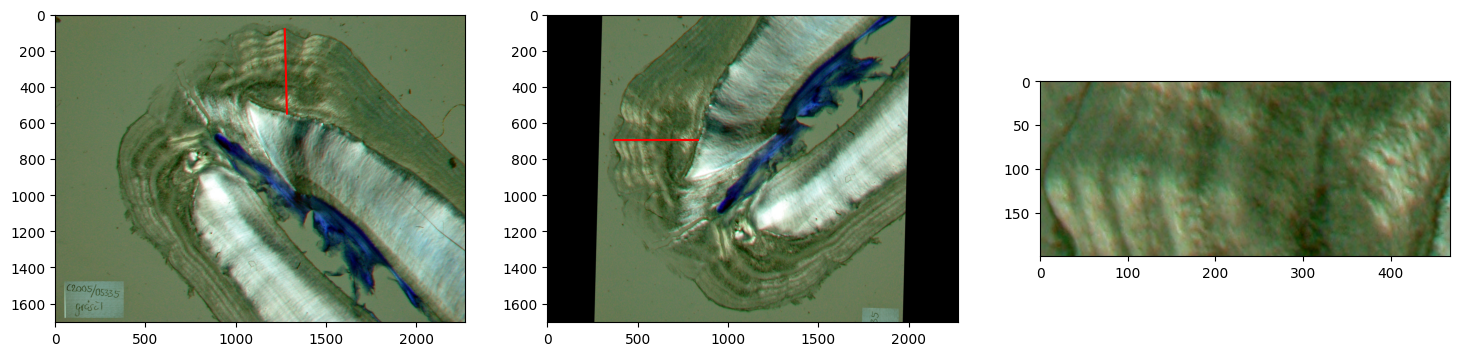

In [78]:
y_min = int(min(p1r[1], p2r[1]) - 100)
y_max = int(max(p1r[1], p2r[1]) + 100)
x_min = int(min(p1r[0], p2r[0]))
x_max = int(max(p1r[0], p2r[0]))

# Clamp to image boundaries
y_min = max(y_min, 0)
y_max = min(y_max, h)
x_min = max(x_min, 0)
x_max = min(x_max, w)




cropped = rotated[y_min:y_max, x_min:x_max]

f, a = plt.subplots(1, 3, figsize=(18, 6))
a = a.ravel()
a[0].imshow(I)
a[0].plot([x_1, x_2], [y_1, y_2], 'red')
a[1].imshow(rotated)
a[1].plot([p1r[0], p2r[0]], [p1r[1], p2r[1]], 'red')
a[2].imshow(cropped)